# HW2 313551170

## 1.

In [ ]:
import librosa
import mirdata
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import IPython.display as ipd
import pandas as pd
import itertools
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import cv2
from tqdm import tqdm

In [5]:
tinysol_dataset = mirdata.initialize("tinysol")
tinysol_dataset.download()
tinysol_metadata = tinysol_dataset._metadata

INFO: Downloading ['audio', 'annotations', 'index']. Index is being stored in C:\Users\WilsonW\anaconda3\envs\mir_env\Lib\site-packages\mirdata\datasets\indexes, and the rest of files in /tmp\mir_datasets\tinysol
INFO: [audio] downloading TinySOL.tar.gz
INFO: /tmp\mir_datasets\tinysol\audio\TinySOL.tar.gz already exists and will not be downloaded. Rerun with force_overwrite=True to delete this file and force the download.
INFO: [annotations] downloading TinySOL_metadata.csv
INFO: /tmp\mir_datasets\tinysol\annotation\TinySOL_metadata.csv already exists and will not be downloaded. Rerun with force_overwrite=True to delete this file and force the download.
INFO: [index] downloading tinysol_index_6.0.json
INFO: C:\Users\WilsonW\anaconda3\envs\mir_env\Lib\site-packages\mirdata\datasets\indexes\tinysol_index_6.0.json already exists and will not be downloaded. Rerun with force_overwrite=True to delete this file and force the download.


這裡把metadata從Dictionary轉成Data Frame的資料型態

In [6]:
meta_records = []

for track_id, metadata in tinysol_metadata.items():
    meta_records.append({
        'track_id': track_id,
        'fold': metadata['Fold'],
        'instrument': metadata['Instrument (in full)'],
        'pitch': metadata['Pitch']
    })

metadata_df = pd.DataFrame(meta_records)

In [14]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues, figsize=(6, 6)):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix')
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.set_title(title)
    fig.colorbar(im)
    tick_marks = np.arange(len(classes))
    ax.set_xticks(tick_marks, classes, rotation=90)
    ax.set_yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')
    plt.show()

In [ ]:
def PrintResult(title, accuracy, precision, recall, f1, cm, label_classes):
    print(f"\n=== {title} ===")

    print(f"Accuracy:  {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-score:  {f1:.3f}")
    plot_confusion_matrix(cm, label_classes)

這裡對資料做feature extraction，因為decision tree需要數值而CNN需要圖，所以decision tree的部分就直接取平均。

In [24]:
spec_image_list = []
mel_image_list = []
cqt_image_list = []
spec_mean_list = []
mel_mean_list = []
cqt_mean_list = []

for track_id in metadata_df.track_id:
    track = tinysol_dataset.track(track_id)
    audio, sr = track.audio

    spec = librosa.amplitude_to_db(np.abs(librosa.stft(audio, n_fft=2048, hop_length=512)), ref=np.max)
    spec_image_list.append(spec)
    spec_mean_list.append(np.mean(spec, axis=1))

    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=2048, n_mels=64, fmax=sr//2), ref=np.max)
    mel_image_list.append(spec)
    mel_mean_list.append(np.mean(spec, axis=1))

    cqt = librosa.amplitude_to_db(np.abs(librosa.cqt(audio, sr=sr)), ref=np.max)
    cqt_image_list.append(spec)
    cqt_mean_list.append(np.mean(spec, axis=1))

# 每個音檔不同長度，所以圖的長也不同，這邊統一轉成128*128
def ImageResize(image_list, shape=(128, 128)):
    resized_list = []
    for image in image_list:
        resized = cv2.resize(image, shape)
        resized_list.append(resized)
    return np.array(resized_list)

spec_image_array = ImageResize(spec_image_list)
mel_image_array = ImageResize(mel_image_list)
cqt_image_array = ImageResize(cqt_image_list)

spec_mean_array = np.array(spec_mean_list)
mel_mean_array = np.array(mel_mean_list)
cqt_mean_array = np.array(cqt_mean_list)

instrument_array = np.array(metadata_df.instrument)
pitch_list = metadata_df.pitch
pitch_list = [pitch[:-1] for pitch in pitch_list]
pitch_array = np.array(pitch_list)
folds = np.array(metadata_df.fold)

le = LabelEncoder()
instrument_array = le.fit_transform(instrument_array)
instrument_classes = le.classes_

pitch_array = le.fit_transform(pitch_array)
pitch_classes = le.classes_

### 1.a.

| 部分 | 說明 |
|:----|:----|
| **Hn** | 樂器縮寫，代表 **French Horn** |
| **ord** | 表示使用的是 **ordinario** |
| **C4** | 音高，**中央C**，頻率約為 261.63 Hz |
| **pp** | 音量強度，**pianissimo** |
| **N** | INSTANCE 欄位，代表無額外資訊（Not Applicable） |
| **N** | MISC 欄位，代表原音錄製（Natural），即沒有經過數位變調或音高修正 |

### 1.b.

In [4]:
def PlotSpectrogram(ax, title, S_db, sr, y_axis):
    img = librosa.display.specshow(S_db, x_axis='time', y_axis=y_axis, sr=sr, fmax=8000, ax=ax)
    plt.colorbar(img, ax=ax, format='%+2.0f dB')
    ax.set(title=title)

In [5]:
tpc_id = 'TpC-ord-C6-mf-N-T11u'
btb_id = 'BTb-ord-F#1-mf-N-T18u'
tpc_track = tinysol_dataset.track(tpc_id)
btb_track = tinysol_dataset.track(btb_id)

In [6]:
ipd.Audio(tpc_track.audio[0], rate=tpc_track.audio[1])

In [7]:
ipd.Audio(btb_track.audio[0], rate=btb_track.audio[1])

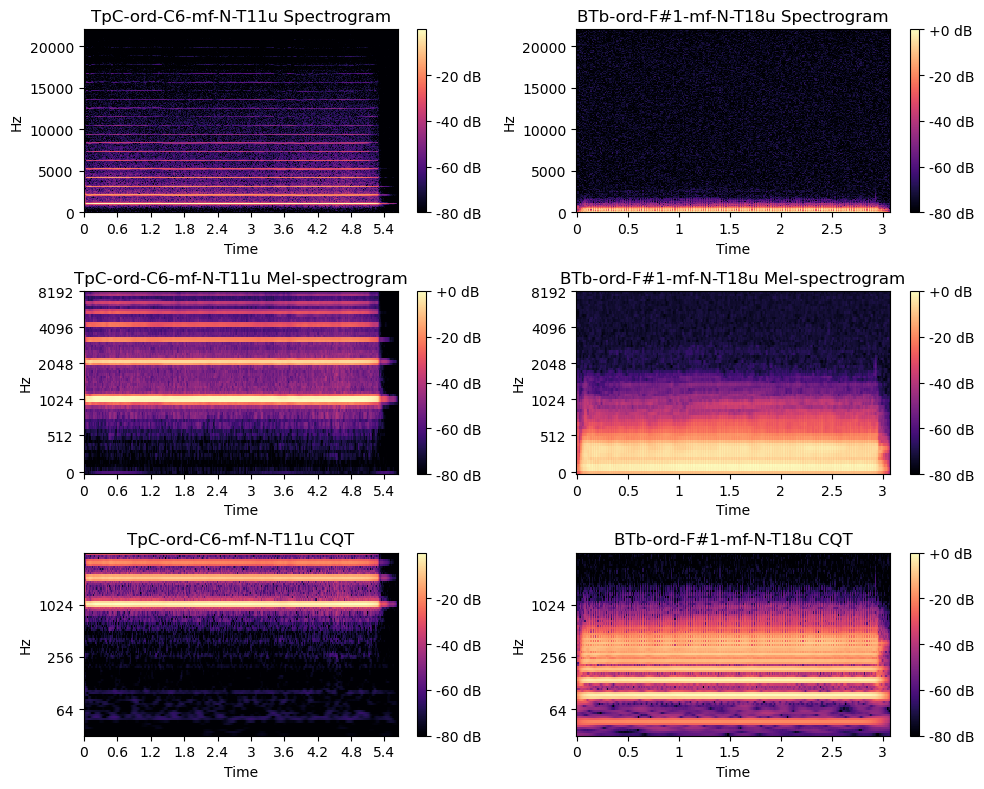

In [8]:
def PlotMultiSpectrogram(track_id, track, axs, col, window_size=1024, hop_size=512):
    audio, sr = track.audio
    spec = librosa.amplitude_to_db(np.abs(librosa.stft(audio, n_fft=window_size, hop_length=hop_size)), ref=np.max)
    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=64, fmax=8000), ref=np.max)
    cqt = librosa.amplitude_to_db(np.abs(librosa.cqt(audio, sr=sr)), ref=np.max)

    PlotSpectrogram(axs[0, col], track_id + ' Spectrogram', spec, sr, 'linear')
    PlotSpectrogram(axs[1, col], track_id + ' Mel-spectrogram', mel, sr, 'mel')
    PlotSpectrogram(axs[2, col], track_id + ' CQT', cqt, sr, 'cqt_hz')


fig, axs = plt.subplots(3, 2, figsize=(10, 8))

PlotMultiSpectrogram(tpc_id, tpc_track, axs, 0)
PlotMultiSpectrogram(btb_id, btb_track, axs, 1)

plt.tight_layout()
plt.show()

這兩個音檔的樂器分別為 Trumpet in C 及 Bass Tuba ， Trumpet in C 的音域較高而 Bass Tuba 的音域較低，這點在圖中可以很明顯的看出來。  
Trumpet in C 的這個音檔會較為適合使用 Mel-spectrogram ，因為可以很明顯地看到基頻在哪裡，泛音也可以很清楚的看到。用 CQT 則太高頻的泛音就看不到；用 Spectrogram 則基頻不好分辨。  
Bass Tuba 的這個音檔會較為適合使用 CQT ，因為只有 CQT 可以看清楚頻率分布，其他方法都會糊在一起。  

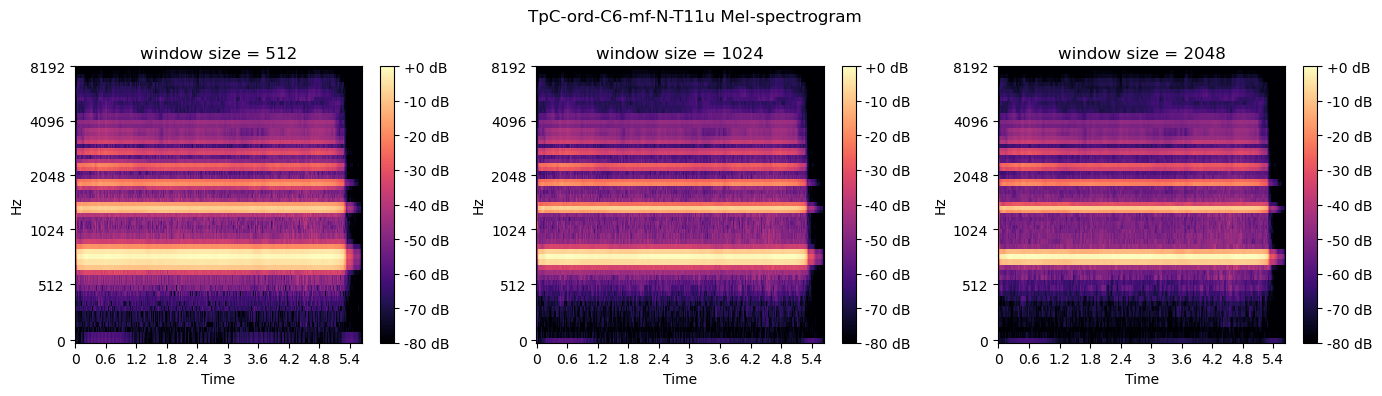

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
audio, sr = tpc_track.audio
mel0 = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=512, n_mels=64, fmax=sr//2), ref=np.max)
mel1 = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=1024, n_mels=64, fmax=sr//2), ref=np.max)
mel2 = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=2048, n_mels=64, fmax=sr//2), ref=np.max)
PlotSpectrogram(axs[0], 'window size = 512', mel0, sr, 'mel')
PlotSpectrogram(axs[1], 'window size = 1024', mel1, sr, 'mel')
PlotSpectrogram(axs[2], 'window size = 2048', mel2, sr, 'mel')

plt.suptitle(tpc_id + ' Mel-spectrogram')
plt.tight_layout()
plt.show()

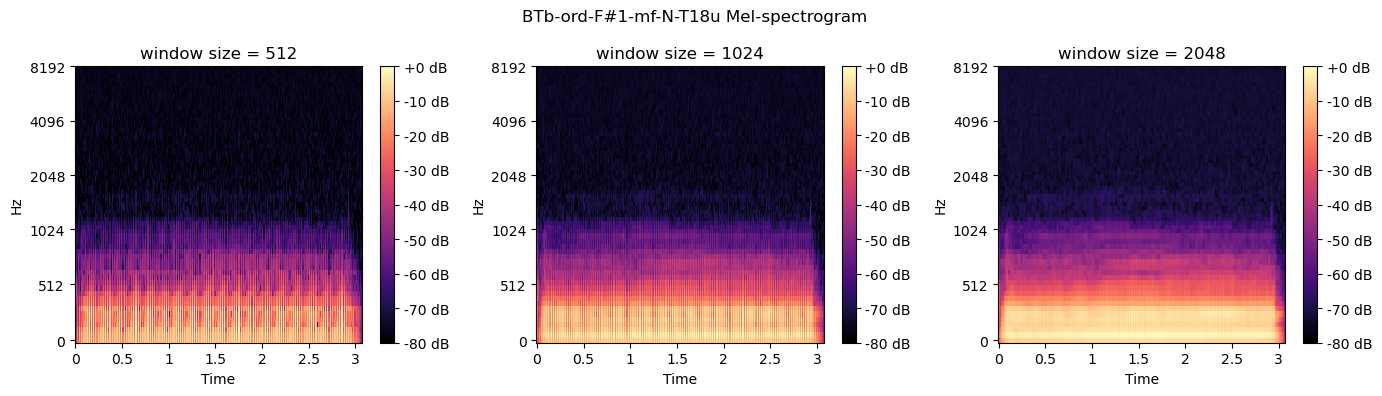

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
audio, sr = btb_track.audio
mel0 = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=512, n_mels=64, fmax=sr//2), ref=np.max)
mel1 = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=1024, n_mels=64, fmax=sr//2), ref=np.max)
mel2 = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=2048, n_mels=64, fmax=sr//2), ref=np.max)
PlotSpectrogram(axs[0], 'window size = 512', mel0, sr, 'mel')
PlotSpectrogram(axs[1], 'window size = 1024', mel1, sr, 'mel')
PlotSpectrogram(axs[2], 'window size = 2048', mel2, sr, 'mel')

plt.suptitle(btb_id + ' Mel-spectrogram')
plt.tight_layout()
plt.show()

因為這兩個音檔都是單一個音而已，沒有旋律變化，所以可以用較大的 window size ，在頻率的維度可以更看得清楚，在時間的維度上因為沒有旋律變化所以不需要分得很清楚。

### 1.c.

#### 1.c.a.

In [25]:
features = ['Spectrogram', 'Mel-Spectrogram', 'CQT']
features_array = {'Spectrogram': spec_mean_array, 'Mel-Spectrogram': mel_mean_array, 'CQT': cqt_mean_array}
results = {}

for feature in features:
    X = features_array[feature]
    results[feature] = {}

    for fold_id in range(5):
        print(f"\n=== {feature} | Fold {fold_id} ===")

        test_index = (folds == fold_id)
        train_index = ~test_index

        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = instrument_array[train_index], instrument_array[test_index]

        # Grid search for best depth
        best_depth, best_score = None, 0
        for depth in range(2, 21):
            model = DecisionTreeClassifier(max_depth=depth, random_state=42)
            model.fit(X_train, y_train)
            val_score = model.score(X_test, y_test)  # Using test fold as validation
            if val_score > best_score:
                best_score = val_score
                best_depth = depth

        # Train final model
        final_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
        final_model.fit(X_train, y_train)
        y_pred = final_model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro')
        rec = recall_score(y_test, y_pred, average='macro')
        f1 = f1_score(y_test, y_pred, average='macro')
        cm = confusion_matrix(y_test, y_pred)

        results[feature][f'fold_{fold_id}'] = {
            'best_depth': best_depth,
            'val_acc': best_score,
            'test_acc': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'confusion_matrix': cm
        }

        print(f"Best depth: {best_depth}, Accuracy: {acc:.3f}, F1: {f1:.3f}")


=== Spectrogram | Fold 0 ===
Best depth: 13, Accuracy: 0.751, F1: 0.668

=== Spectrogram | Fold 1 ===
Best depth: 18, Accuracy: 0.753, F1: 0.679

=== Spectrogram | Fold 2 ===
Best depth: 12, Accuracy: 0.743, F1: 0.661

=== Spectrogram | Fold 3 ===
Best depth: 18, Accuracy: 0.770, F1: 0.671

=== Spectrogram | Fold 4 ===
Best depth: 16, Accuracy: 0.691, F1: 0.617

=== Mel-Spectrogram | Fold 0 ===
Best depth: 13, Accuracy: 0.751, F1: 0.668

=== Mel-Spectrogram | Fold 1 ===
Best depth: 18, Accuracy: 0.753, F1: 0.679

=== Mel-Spectrogram | Fold 2 ===
Best depth: 12, Accuracy: 0.743, F1: 0.661

=== Mel-Spectrogram | Fold 3 ===
Best depth: 18, Accuracy: 0.770, F1: 0.671

=== Mel-Spectrogram | Fold 4 ===
Best depth: 16, Accuracy: 0.691, F1: 0.617

=== CQT | Fold 0 ===
Best depth: 13, Accuracy: 0.751, F1: 0.668

=== CQT | Fold 1 ===
Best depth: 18, Accuracy: 0.753, F1: 0.679

=== CQT | Fold 2 ===
Best depth: 12, Accuracy: 0.743, F1: 0.661

=== CQT | Fold 3 ===
Best depth: 18, Accuracy: 0.770, 


=== Decision Tree Instrument Classification Summary | Spectrogram ===
Accuracy:  0.742
Precision: 0.668
Recall:    0.659
F1-score:  0.659
Confusion matrix


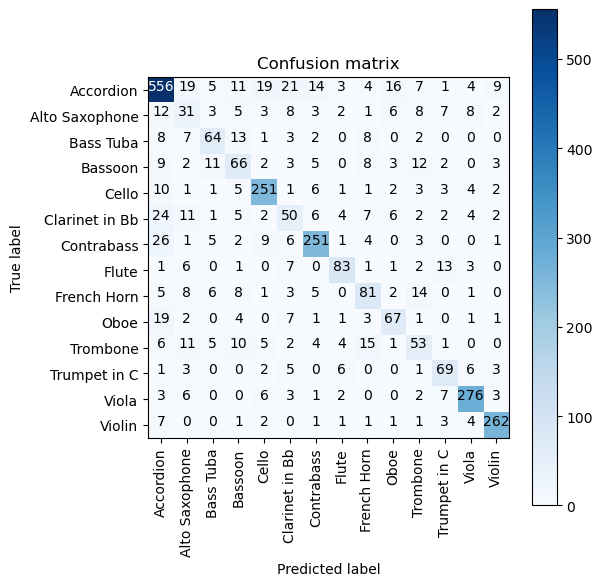


=== Decision Tree Instrument Classification Summary | Mel-Spectrogram ===
Accuracy:  0.742
Precision: 0.668
Recall:    0.659
F1-score:  0.659
Confusion matrix


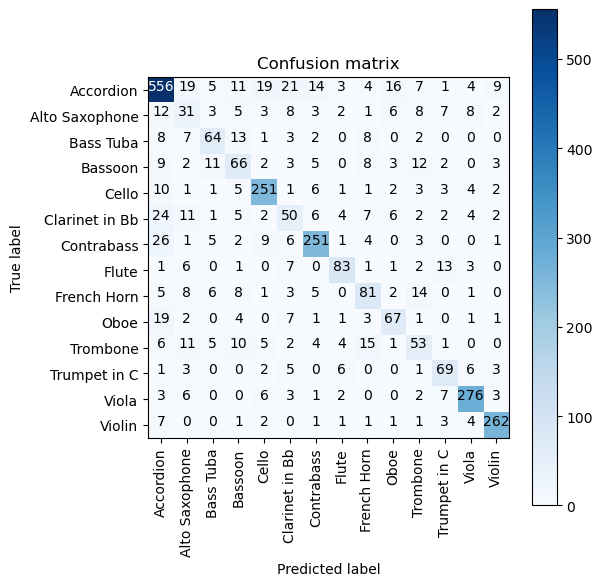


=== Decision Tree Instrument Classification Summary | CQT ===
Accuracy:  0.742
Precision: 0.668
Recall:    0.659
F1-score:  0.659
Confusion matrix


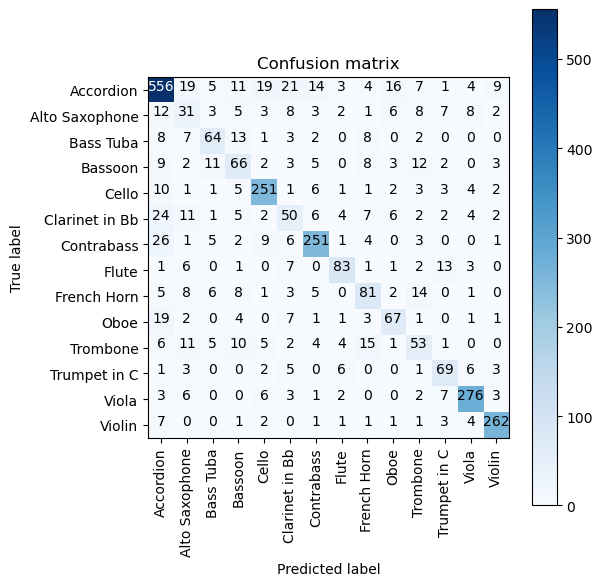

In [26]:
for feature in features:
    all_acc = [results[feature][fold]['test_acc'] for fold in results[feature]]
    all_precision = [results[feature][fold]['precision'] for fold in results[feature]]
    all_recall = [results[feature][fold]['recall'] for fold in results[feature]]
    all_f1 = [results[feature][fold]['f1'] for fold in results[feature]]
    total_cm = sum(results[feature][fold]['confusion_matrix'] for fold in results[feature])

    PrintResult(f"Decision Tree Instrument Classification Summary | {feature}", np.mean(all_acc), np.mean(all_precision), np.mean(all_recall), np.mean(all_f1), total_cm, instrument_classes)

結果看起來都還不錯，三種feature都有0.7以上的accuracy。  
每一個true label數字最大的都還是自己，看起來沒有哪個樂器特別容易被判斷成別的樂器。然而從predicted label的角度來看，很多樂器都被認為是Accordion。  

#### 1.c.b.

In [28]:
features_array = {'Spectrogram': spec_image_array, 'Mel-Spectrogram': mel_image_array, 'CQT': cqt_image_array}
results = {}

for feature_name, feature_array in features_array.items():
    print(f"\n=== Feature: {feature_name} ===")
    results[feature_name] = {}

    X = np.expand_dims(feature_array, axis=-1).astype("float32")
    X = X / np.max(X, axis=(1,2,3), keepdims=True)  # normalize
    y = tf.keras.utils.to_categorical(instrument_array) # one-hot

    for fold_id in range(5):
        print(f"Fold {fold_id}")
        test_index = (folds == fold_id)
        train_index = ~test_index

        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model = Sequential([
            Conv2D(6, kernel_size=(5,5), activation='relu', input_shape=X.shape[1:]),
            MaxPooling2D(pool_size=(2,2)),
            Conv2D(16, kernel_size=(5,5), activation='relu'),
            MaxPooling2D(pool_size=(2,2)),
            Flatten(),
            Dense(120, activation='relu'),
            Dense(84, activation='relu'),
            Dense(y.shape[1], activation='softmax')
        ])

        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

        y_pred = model.predict(X_test)
        y_pred_labels = np.argmax(y_pred, axis=1)
        y_true_labels = np.argmax(y_test, axis=1)

        accuracy = accuracy_score(y_true_labels, y_pred_labels)
        recall = recall_score(y_true_labels, y_pred_labels, average='macro') #can try other ave method
        precision = precision_score(y_true_labels, y_pred_labels, average='macro')
        f1 = f1_score(y_true_labels, y_pred_labels, average='macro')
        cm = confusion_matrix(y_true_labels, y_pred_labels)

        results[feature_name][f'fold_{fold_id}'] = {
            'test_acc': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'confusion_matrix': cm
        }

        print(f"→ Accuracy: {accuracy:.3f}, F1: {f1:.3f}")


=== Feature: Spectrogram ===
Fold 0
19/19 [==============================] - 0s 9ms/step
→ Accuracy: 0.666, F1: 0.511
Fold 1
19/19 [==============================] - 0s 9ms/step
→ Accuracy: 0.605, F1: 0.442
Fold 2
19/19 [==============================] - 0s 9ms/step
→ Accuracy: 0.782, F1: 0.669
Fold 3
19/19 [==============================] - 0s 9ms/step
→ Accuracy: 0.782, F1: 0.645
Fold 4


c:\Users\WilsonW\anaconda3\envs\mir_env\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


19/19 [==============================] - 0s 9ms/step
→ Accuracy: 0.861, F1: 0.809

=== Feature: Mel-Spectrogram ===
Fold 0
19/19 [==============================] - 0s 9ms/step
→ Accuracy: 0.890, F1: 0.839
Fold 1
19/19 [==============================] - 0s 9ms/step
→ Accuracy: 0.847, F1: 0.763
Fold 2
19/19 [==============================] - 0s 10ms/step
→ Accuracy: 0.914, F1: 0.871
Fold 3
19/19 [==============================] - 0s 10ms/step
→ Accuracy: 0.770, F1: 0.680
Fold 4
19/19 [==============================] - 0s 9ms/step
→ Accuracy: 0.233, F1: 0.033

=== Feature: CQT ===
Fold 0


c:\Users\WilsonW\anaconda3\envs\mir_env\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


19/19 [==============================] - 0s 10ms/step
→ Accuracy: 0.803, F1: 0.719
Fold 1
19/19 [==============================] - 0s 10ms/step
→ Accuracy: 0.852, F1: 0.756
Fold 2
19/19 [==============================] - 0s 10ms/step
→ Accuracy: 0.840, F1: 0.754
Fold 3
19/19 [==============================] - 0s 9ms/step
→ Accuracy: 0.235, F1: 0.027
Fold 4


c:\Users\WilsonW\anaconda3\envs\mir_env\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


19/19 [==============================] - 0s 9ms/step
→ Accuracy: 0.767, F1: 0.679



=== CNN Instrument Classification Summary | Spectrogram ===
Accuracy:  0.739
Precision: 0.679
Recall:    0.619
F1-score:  0.615
Confusion matrix


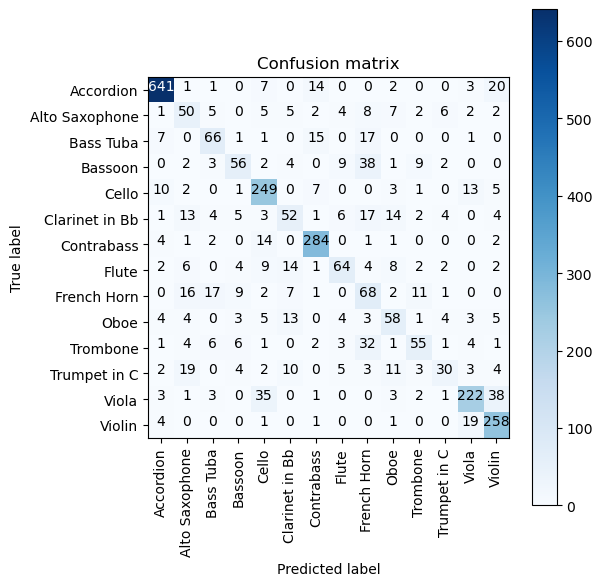


=== CNN Instrument Classification Summary | Mel-Spectrogram ===
Accuracy:  0.731
Precision: 0.665
Recall:    0.647
F1-score:  0.637
Confusion matrix


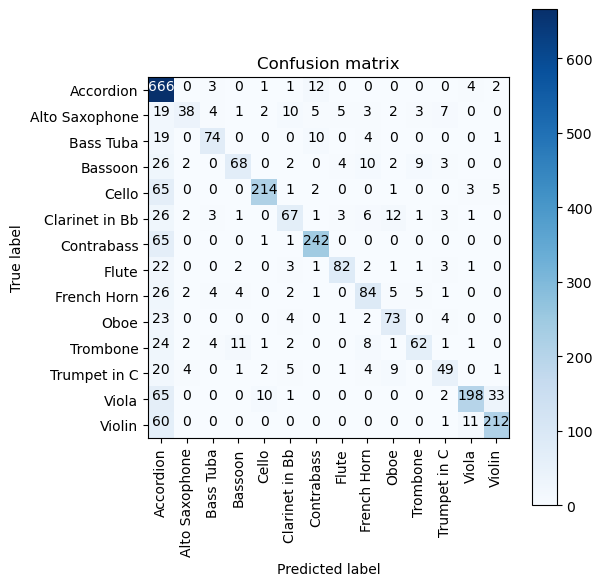


=== CNN Instrument Classification Summary | CQT ===
Accuracy:  0.700
Precision: 0.617
Recall:    0.599
F1-score:  0.587
Confusion matrix


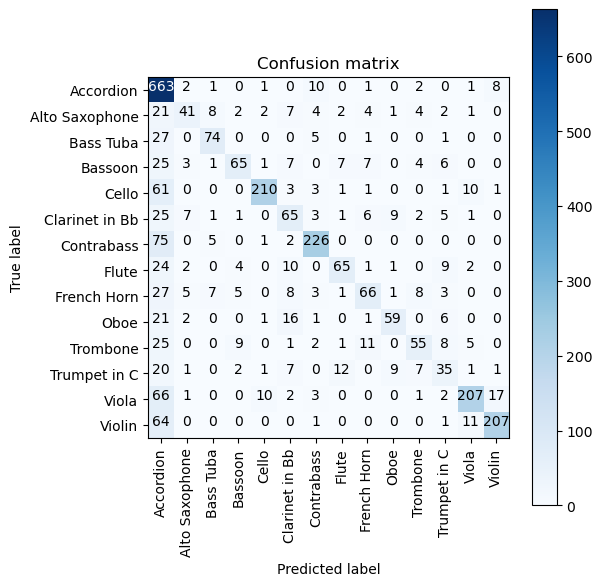

In [29]:
for feature in features:
    all_acc = [results[feature][fold]['test_acc'] for fold in results[feature]]
    all_precision = [results[feature][fold]['precision'] for fold in results[feature]]
    all_recall = [results[feature][fold]['recall'] for fold in results[feature]]
    all_f1 = [results[feature][fold]['f1'] for fold in results[feature]]
    total_cm = sum(results[feature][fold]['confusion_matrix'] for fold in results[feature])

    PrintResult(f"CNN Instrument Classification Summary | {feature}", np.mean(all_acc), np.mean(all_precision), np.mean(all_recall), np.mean(all_f1), total_cm, instrument_classes)

三種feature extraction的準確率不相上下，都是0.7左右。  
從confusion matrix可以看到其他樂器很容易被誤認為是Accordion。

### 1.d.

#### 1.d.a.

In [30]:
def estimate_pitch_autocorrelation(y, sr, fmin=50, fmax=2000):
    import scipy.signal

    # Downsample to save time
    sr_ds = 11025
    y = librosa.resample(y, orig_sr=sr, target_sr=sr_ds)
    sr = sr_ds

    # Remove DC offset
    y = y - np.mean(y)

    # Compute autocorrelation via FFT
    corr = scipy.signal.fftconvolve(y, y[::-1], mode='full')
    corr = corr[len(corr)//2:]  # keep positive lags

    min_lag = int(sr / fmax)
    max_lag = int(sr / fmin)

    if max_lag >= len(corr):
        return 0

    peak_lag = np.argmax(corr[min_lag:max_lag]) + min_lag
    f0 = sr / peak_lag
    return f0

In [31]:
y_pred = []

for track_id in tqdm(metadata_df.track_id):
    track = tinysol_dataset.track(track_id)
    audio, sr = track.audio

    f0 = estimate_pitch_autocorrelation(audio, sr)
    y_pred.append(librosa.hz_to_note(f0, octave=True, unicode=False))

y_pred = [pitch[:-1] for pitch in y_pred]

100%|██████████| 2913/2913 [00:14<00:00, 194.48it/s]


In [33]:
le = LabelEncoder()
y_pred_encoded = le.fit_transform(y_pred)
y_true_encoded = pitch_array


=== ACF Pitch Classification Summary ===
Accuracy:  0.763
Precision: 0.762
Recall:    0.771
F1-score:  0.760
Confusion matrix


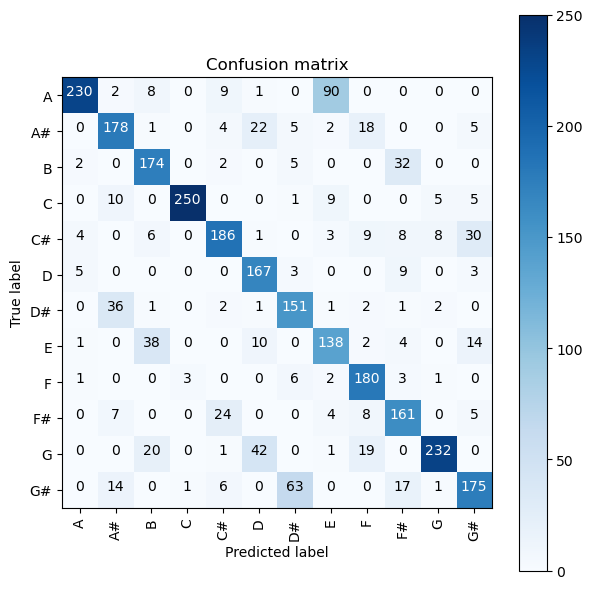

In [35]:
accuracy = accuracy_score(y_pred_encoded, y_true_encoded)
precision = precision_score(y_pred_encoded, y_true_encoded, average='macro')
recall = recall_score(y_pred_encoded, y_true_encoded, average='macro')
f1 = f1_score(y_pred_encoded, y_true_encoded, average='macro')
cm = confusion_matrix(y_pred_encoded, y_true_encoded)
PrintResult("ACF Pitch Classification Summary", accuracy, precision, recall, f1, cm, pitch_classes)

#### 1.d.b.

In [36]:
def estimate_pitch_pyin(y, sr, fmin=50, fmax=2000):
    # pyin 會輸出一組 f0 time series（長度 = 幀數）
    f0, voiced_flag, voiced_prob = librosa.pyin(
        y, fmin=fmin, fmax=fmax, sr=sr, frame_length=2048, hop_length=512
    )
    # 取有效音高（排除 None），再取中位數
    f0_valid = f0[~np.isnan(f0)]
    if len(f0_valid) == 0:
        return 0
    return np.median(f0_valid)  # 或 mean

In [37]:
y_pred = []

for track_id in tqdm(metadata_df.track_id):
    track = tinysol_dataset.track(track_id)
    audio, sr = track.audio

    f0 = estimate_pitch_autocorrelation(audio, sr)
    y_pred.append(librosa.hz_to_note(f0, octave=True, unicode=False))

y_pred = [pitch[:-1] for pitch in y_pred]

100%|██████████| 2913/2913 [00:15<00:00, 191.81it/s]


In [38]:
le = LabelEncoder()
y_pred_encoded = le.fit_transform(y_pred)
y_true_encoded = pitch_array


=== pYIN Pitch Classification Summary ===
Accuracy:  0.763
Precision: 0.762
Recall:    0.771
F1-score:  0.760
Confusion matrix


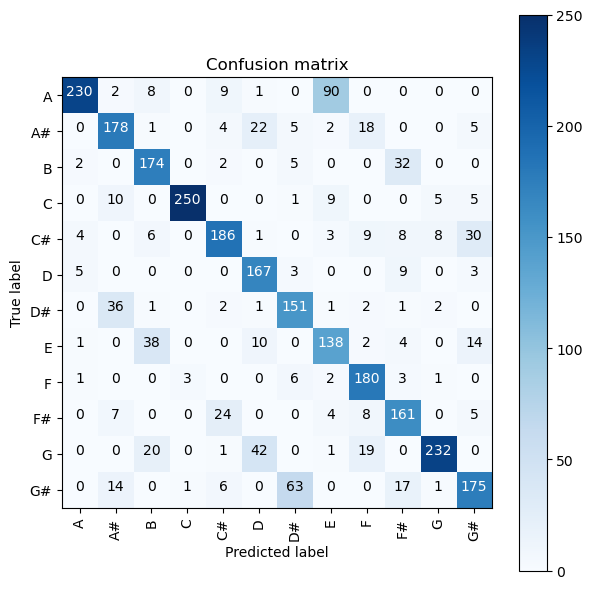

In [39]:
accuracy = accuracy_score(y_pred_encoded, y_true_encoded)
precision = precision_score(y_pred_encoded, y_true_encoded, average='macro')
recall = recall_score(y_pred_encoded, y_true_encoded, average='macro')
f1 = f1_score(y_pred_encoded, y_true_encoded, average='macro')
cm = confusion_matrix(y_pred_encoded, y_true_encoded)
PrintResult("pYIN Pitch Classification Summary", accuracy, precision, recall, f1, cm, pitch_classes)

#### 1.d.c.

In [40]:
features_array = {'Spectrogram': spec_image_array, 'Mel-Spectrogram': mel_image_array, 'CQT': cqt_image_array}
results = {}

for feature_name, feature_array in features_array.items():
    print(f"\n=== Feature: {feature_name} ===")
    results[feature_name] = {}

    X = np.expand_dims(feature_array, axis=-1).astype("float32")
    X = X / np.max(X, axis=(1,2,3), keepdims=True)  # normalize
    y = tf.keras.utils.to_categorical(pitch_array) # one-hot

    for fold_id in range(5):
        print(f"Fold {fold_id}")
        test_index = (folds == fold_id)
        train_index = ~test_index

        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model = Sequential([
            Conv2D(6, kernel_size=(5,5), activation='relu', input_shape=X.shape[1:]),
            MaxPooling2D(pool_size=(2,2)),
            Conv2D(16, kernel_size=(5,5), activation='relu'),
            MaxPooling2D(pool_size=(2,2)),
            Flatten(),
            Dense(120, activation='relu'),
            Dense(84, activation='relu'),
            Dense(y.shape[1], activation='softmax')
        ])

        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

        y_pred = model.predict(X_test)
        y_pred_labels = np.argmax(y_pred, axis=1)
        y_true_labels = np.argmax(y_test, axis=1)

        accuracy = accuracy_score(y_true_labels, y_pred_labels)
        recall = recall_score(y_true_labels, y_pred_labels, average='macro') #can try other ave method
        precision = precision_score(y_true_labels, y_pred_labels, average='macro')
        f1 = f1_score(y_true_labels, y_pred_labels, average='macro')
        cm = confusion_matrix(y_true_labels, y_pred_labels)

        results[feature_name][f'fold_{fold_id}'] = {
            'test_acc': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'confusion_matrix': cm
        }

        print(f"→ Accuracy: {accuracy:.3f}, F1: {f1:.3f}")


=== Feature: Spectrogram ===
Fold 0
19/19 [==============================] - 0s 10ms/step
→ Accuracy: 0.823, F1: 0.824
Fold 1
19/19 [==============================] - 0s 9ms/step
→ Accuracy: 0.868, F1: 0.868
Fold 2
19/19 [==============================] - 0s 10ms/step
→ Accuracy: 0.712, F1: 0.707
Fold 3
19/19 [==============================] - 0s 10ms/step
→ Accuracy: 0.864, F1: 0.864
Fold 4
19/19 [==============================] - 0s 10ms/step
→ Accuracy: 0.352, F1: 0.352

=== Feature: Mel-Spectrogram ===
Fold 0
19/19 [==============================] - 0s 10ms/step
→ Accuracy: 0.873, F1: 0.873
Fold 1
19/19 [==============================] - 0s 10ms/step
→ Accuracy: 0.782, F1: 0.782
Fold 2
19/19 [==============================] - 0s 10ms/step
→ Accuracy: 0.079, F1: 0.012
Fold 3


c:\Users\WilsonW\anaconda3\envs\mir_env\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


19/19 [==============================] - 0s 10ms/step
→ Accuracy: 0.581, F1: 0.570
Fold 4
19/19 [==============================] - 0s 10ms/step
→ Accuracy: 0.715, F1: 0.719

=== Feature: CQT ===
Fold 0
19/19 [==============================] - 0s 10ms/step
→ Accuracy: 0.840, F1: 0.841
Fold 1
19/19 [==============================] - 0s 10ms/step
→ Accuracy: 0.552, F1: 0.542
Fold 2
19/19 [==============================] - 1s 40ms/step
→ Accuracy: 0.873, F1: 0.872
Fold 3
19/19 [==============================] - 1s 39ms/step


c:\Users\WilsonW\anaconda3\envs\mir_env\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


→ Accuracy: 0.069, F1: 0.011
Fold 4
19/19 [==============================] - 1s 40ms/step
→ Accuracy: 0.875, F1: 0.876



=== CNN Pitch Classification Summary | Spectrogram ===
Accuracy:  0.724
Precision: 0.764
Recall:    0.726
F1-score:  0.723
Confusion matrix


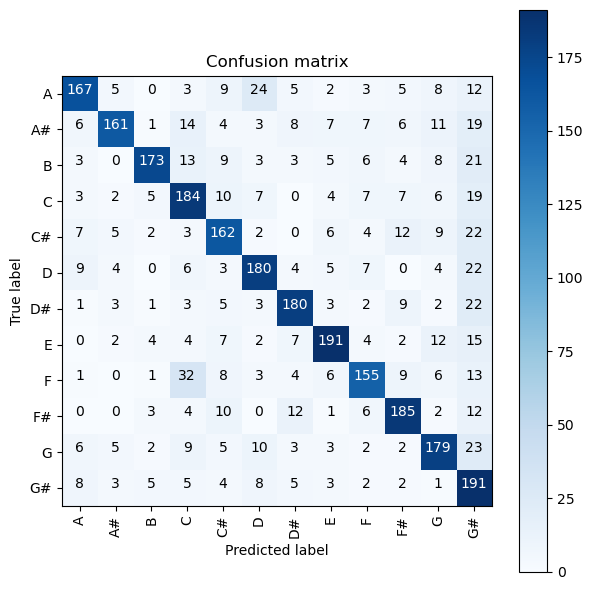


=== CNN Pitch Classification Summary | Mel-Spectrogram ===
Accuracy:  0.606
Precision: 0.618
Recall:    0.610
F1-score:  0.591
Confusion matrix


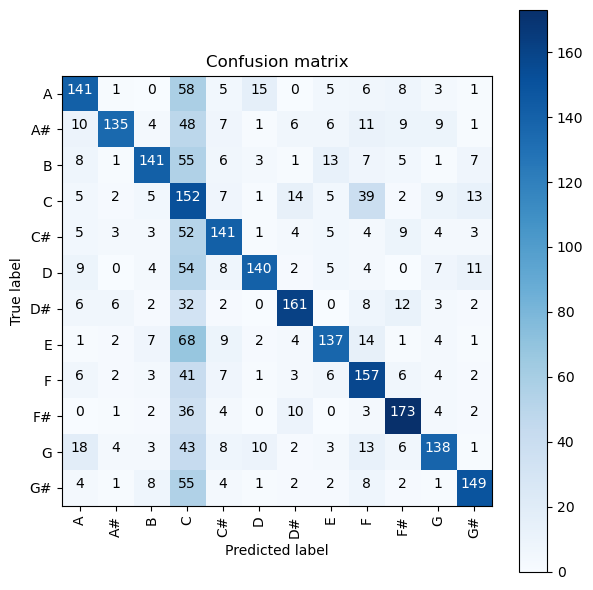


=== CNN Pitch Classification Summary | CQT ===
Accuracy:  0.642
Precision: 0.642
Recall:    0.645
F1-score:  0.628
Confusion matrix


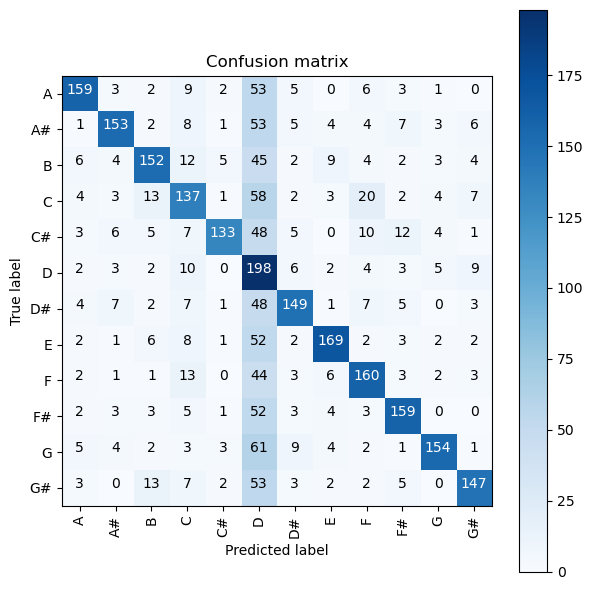

In [41]:
for feature in features:
    all_acc = [results[feature][fold]['test_acc'] for fold in results[feature]]
    all_precision = [results[feature][fold]['precision'] for fold in results[feature]]
    all_recall = [results[feature][fold]['recall'] for fold in results[feature]]
    all_f1 = [results[feature][fold]['f1'] for fold in results[feature]]
    total_cm = sum(results[feature][fold]['confusion_matrix'] for fold in results[feature])

    PrintResult(f"CNN Pitch Classification Summary | {feature}", np.mean(all_acc), np.mean(all_precision), np.mean(all_recall), np.mean(all_f1), total_cm, pitch_classes)

準確率都差不多在0.6, 0.7左右。  
CQT、Mel-Spectrogram這兩種方法的confusion matrix都有一行顏色特別深，代表其他音很容易被認為是這個音。  